# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform **differentiable ray tracing** to compute the **derivatives of the image intensity** with respect to key parameters, such as:  

- **Observer inclination (`θ`)**  

We then use these derivatives to **recover the ground truth parameters** of our analytical test model using the **conjugate gradient algorithm**.  

This approach allows us to perform **gradient-based parameter estimation**, linking observed intensity changes directly to the underlying physical parameters.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [2]:
include("../src/main.jl")
println("Available threads: ", nthreads())
println("RHO_unit:", RHO_unit)

Using model: iharm, change src/set_globals.jl to modify.
Available threads: 1
RHO_unit:3.906325282703709e-19


### Autodiff Image and Derivative Calculation

This cell computes the **image intensity** and its **derivatives** observer inclination (`θ`) using the **AutodiffGeoTrajEulerMethodGRMHD**.  

- **Pre-allocation**: Arrays are created to store the intensity (`I_arr`) and derivatives (`dI_da_arr`, `dI_dθo_arr`) for each pixel.  
- **Threaded computation**: Trajectories are pre-allocated per thread to enable parallel execution.  
- **Autodiff integration**: For each pixel `(i, j)`, the method computes:  
  - `intensity_out` → final pixel intensity  
  - `dI_da_out` → derivative with respect to spin  
  - `dI_dθo_out` → derivative with respect to inclination  

The resulting **intensity array (`I_arr`) will serve as the ground truth** for the **conjugate gradient parameter recovery** in subsequent cells.  

Progress is monitored across threads to track completion.


In [3]:
#dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";
dump_filepath = "../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5";

#dump_filepath = "../../../../Downloads/torus.out0.00356.h5";

In [4]:
const params = read_header(dump_filepath);

Initializing grid from: ../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5


Using mixed tp_over_te with trat_small = 1, trat_large = 40, and beta_crit = 1
Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.177706 Rout: 1000.000000
Grid start (startx): 1.635684465252566e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02


In [5]:
#TODO: put this in reading file
trat_large = 20. 
const trat_small = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.0 
const sigma_cut_high = -1.0;



In [26]:
const simulation_data = load_data(dump_filepath, trat_large);

Using model: iharm, change src/set_globals.jl to modify.
Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [29]:
#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const pixels_x = 80
const pixels_y = 80
# Distance to the source in parsecs
const SourceD = 16.9e6 * PC
const Rout = 1000.0
const Rstop = 100.0
const Rh = 1 + sqrt(1. - params.a * params.a);

#Check if these are correct
#const cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
#const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#TODO: prob have to be read from file
#const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
const freq = 230e9;

# Size of the screen in Rg in both directions
const DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
const DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro
const xoff = 0.0
const yoff = 0.0
const nmaxstep = 15000


15000

In [38]:
include("../src/main.jl")
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
const nx, ny = pixels_x, pixels_y
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_dRhigh_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

# Constants
const DX =DXsize
const DY = DYsize
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, SourceD, L_unit)

# Pre-allocate trajectory arrays for each thread
num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, (num_threads+1))
for tid in 1:(num_threads + 1)
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end

progress = zeros(Int, Threads.nthreads())
total = nx * ny
p = Progress(
    total; 
    desc = "Computing Image and Sensitivity...", 
    showspeed = true, 
    barlen = 30
)

Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_dRhigh_out = Ref{Float64}(0.0)
        
        AutoDiffGeoTrajEulerMethod_GRMHD!(
            thread_trajs[tid], dI_dθo_out, intensity_out, dI_dRhigh_out,
            ro, th, phi, params.a, nx, ny, nmaxstep, i, j, 
            freq, fovx, fovy, Rout, Rstop, simulation_data
        )
        
        dI_dRhigh_arr[i + 1, j + 1] = dI_dRhigh_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]

        # Update the progress bar
        ProgressMeter.next!(
            p; 
            showvalues = [
                (:thread_id, tid), 
                (:pixel, "($i, $j)"), 
                (:total_done, "$(i*ny + j)/$total")
            ]
        )
    end
end

finish!(p)

Computing Image and Sensitivity... 100%|██████████████████████████████| Time: 0:04:13 (39.60 ms/it)
    thread_id: 1
        pixel: (79, 79)
   total_done: 6399/6400


# Plotting the Image

Plotting the image and the derivatives with proper angular spacing

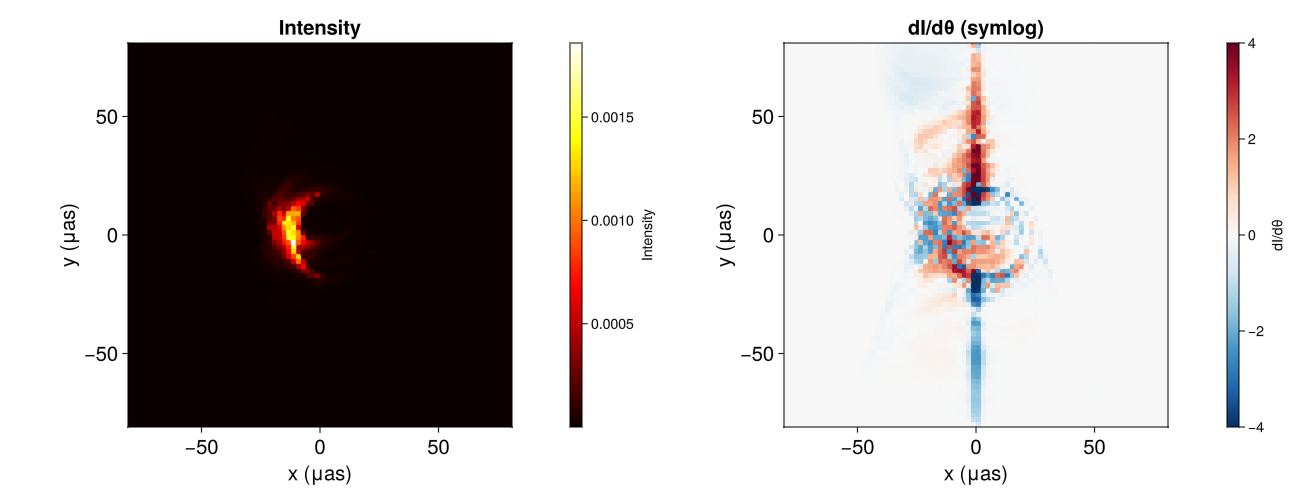

In [39]:
using GLMakie

# Calculate field of view limits
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 44.17
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# Symlog parameters
# -----------------------------
vmin = -1e-3
vmax =  1e-3
linthresh = 1e-3 * vmax   # = 1e-6

# -----------------------------
# Symlog transform
# -----------------------------
function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh=linthresh)

cr_symlog = (
    - (1 + log10(abs(vmin) / linthresh)),
      (1 + log10(abs(vmax) / linthresh))
)

# -----------------------------
# Figure layout (side colorbars)
# -----------------------------
fig = Figure(size = (1300, 500))

# -----------------------------
# Plot 1: Intensity
# -----------------------------
ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr;
    colormap = :hot
)

Colorbar(fig[1, 2], hm1;
    label = "Intensity"
)

# -----------------------------
# Plot 2: dI/dθ (symlog)
# -----------------------------
ax2 = Axis(fig[1, 3],
    title = "dI/dθ (symlog)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog
)

Colorbar(fig[1, 4], hm2;
    label = "dI/dθ"
)



fig


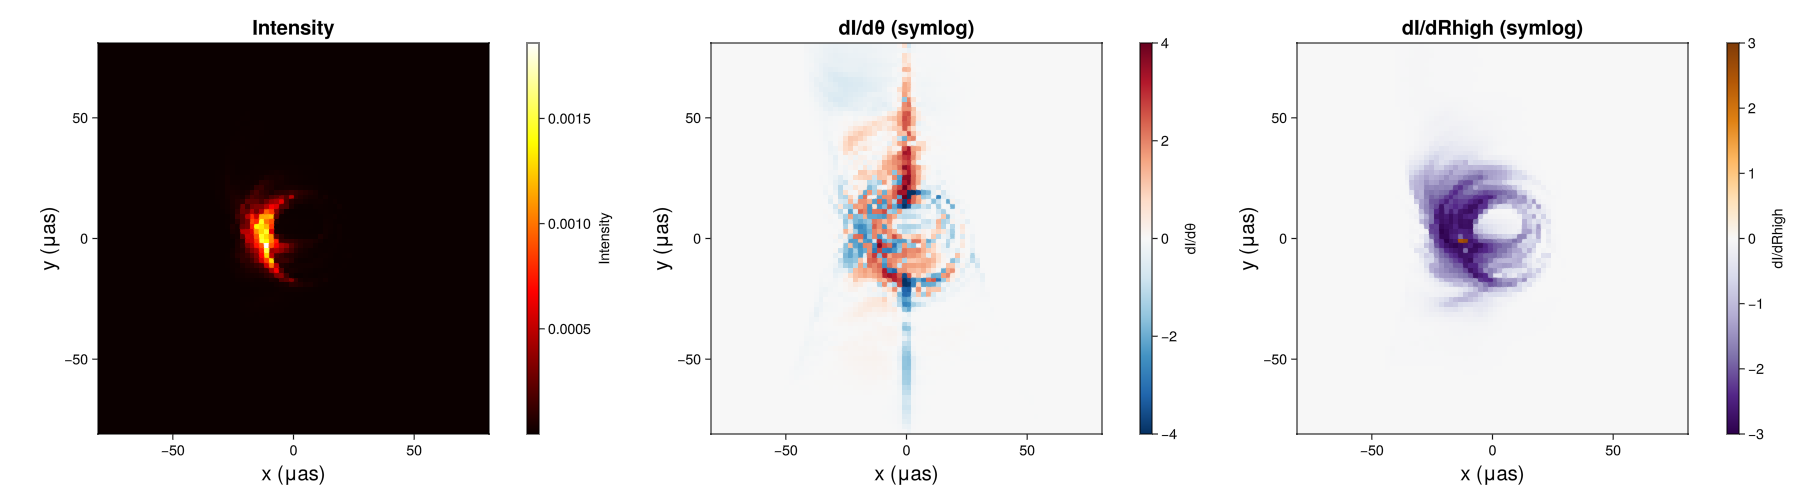

In [13]:
using GLMakie

# -----------------------------
# 1. Physics & Coordinates Setup
# -----------------------------
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 44.17
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# 2. Symlog Transformation
# -----------------------------
function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

# -----------------------------
# 3. Data Processing
# -----------------------------

# --- Process dI/dθo ---
# (Using your hardcoded limits for dI/dθo)
vmin_theta = -1e-3
vmax_theta =  1e-3
linthresh_theta = 1e-3 * vmax_theta

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh=linthresh_theta)
cr_symlog_theta = (
    -(1 + log10(abs(vmin_theta) / linthresh_theta)),
     (1 + log10(abs(vmax_theta) / linthresh_theta))
)

# --- Process dI/dRhigh ---
# (Auto-scaling limits for dI/dRhigh since units differ)
max_val_R = maximum(abs.(filter(!isnan, dI_dRhigh_arr))) 
if max_val_R == 0; max_val_R = 1.0; end # Prevent div/0 if array is empty

vmin_R = -max_val_R
vmax_R =  max_val_R
linthresh_R = 1e-2 * vmax_R # Linear threshold at 1% of max

dI_dR_symlog = symlog(dI_dRhigh_arr; linthresh=linthresh_R)
cr_symlog_R = (
    -(1 + log10(abs(vmin_R) / linthresh_R)),
     (1 + log10(abs(vmax_R) / linthresh_R))
)

# -----------------------------
# 4. Figure Layout
# -----------------------------
# Widen figure to fit 3 plots + 3 colorbars
fig = Figure(size = (1800, 500)) 

# --- Plot 1: Intensity ---
ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20
)
hm1 = heatmap!(ax1, x_coords, y_coords, I_arr; colormap = :hot)
Colorbar(fig[1, 2], hm1; label = "Intensity")

# --- Plot 2: dI/dθ (symlog) ---
ax2 = Axis(fig[1, 3],
    title = "dI/dθ (symlog)",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20
)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog_theta
)
Colorbar(fig[1, 4], hm2; label = "dI/dθ")

# --- Plot 3: dI/dRhigh (symlog) ---
ax3 = Axis(fig[1, 5],
    title = "dI/dRhigh (symlog)",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20
)
hm3 = heatmap!(ax3, x_coords, y_coords, dI_dR_symlog;
    colormap = Reverse(:PuOr), # Using Purple-Orange to distinguish from dI/dθ
    colorrange = cr_symlog_R
)
Colorbar(fig[1, 6], hm3; label = "dI/dRhigh")

fig

In [21]:
dI_dRhigh_FD, _ =  FiniteDifferencesTrat(ro, th, phi, DXsize, DYsize, pixels_x, pixels_y, SourceD, freq, 15000, 1e-6, bhspin, Rout, Rstop, dump_filepath)


Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
Primitives successfully loaded. Dimensions: (288, 128, 128)
Calculating physical quantities...
Using mixed tp_over_te with trat_small = 1.0, trat_large = 20.000001, and beta_crit = 1.0
Calculating using trat_large = 20.000001
All primitives successfully loaded. Dimensions: (288, 128, 128)
Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
Primitives successfully loaded. Dimensions: (288, 128, 128)
Calculating physical quantities...
Using mixed tp_over_te with trat_small = 1.0, trat_large = 19.999999, and beta_crit = 1.0
Calculating using trat_large = 19.999999
All primitives successfully loaded. Dimensions: (288, 128, 128)
Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
Primitives successfully loaded. Dimensions: (288, 128, 128)
Calculating physical quantities...
Using mixed tp_over_te with 

([-1.5765526925603074e-23 -8.20430458463528e-24 … -3.033854182532065e-24 -1.714557694663196e-24; -4.008068647050654e-23 -1.967339574064797e-23 … -5.18998894000972e-23 -2.5640980433250646e-23; … ; -5.619957406958648e-33 -1.4280161776359784e-33 … -3.835518264573321e-25 -2.3824109384820315e-25; -2.188655479949878e-33 -1.491380220401695e-33 … -1.8391272044623142e-26 -6.458174713618516e-27], [5.86242301516776e-23 2.9512424029297373e-23 … 5.115698527410714e-24 2.7712723005206278e-24; 1.4414080592846992e-22 7.135028625236483e-23 … 8.493853609969309e-23 4.116120553599959e-23; … ; 5.876776994033906e-33 1.9014416674940097e-33 … 8.610575546185292e-25 5.514263144976012e-25; 3.0995721039301816e-33 2.2821544816009292e-33 … 3.9901690126823477e-26 1.50179904299961e-26])

Running Finite Differences verification...
Median Relative Error (in signal region): 7.480819924157952e-7 %


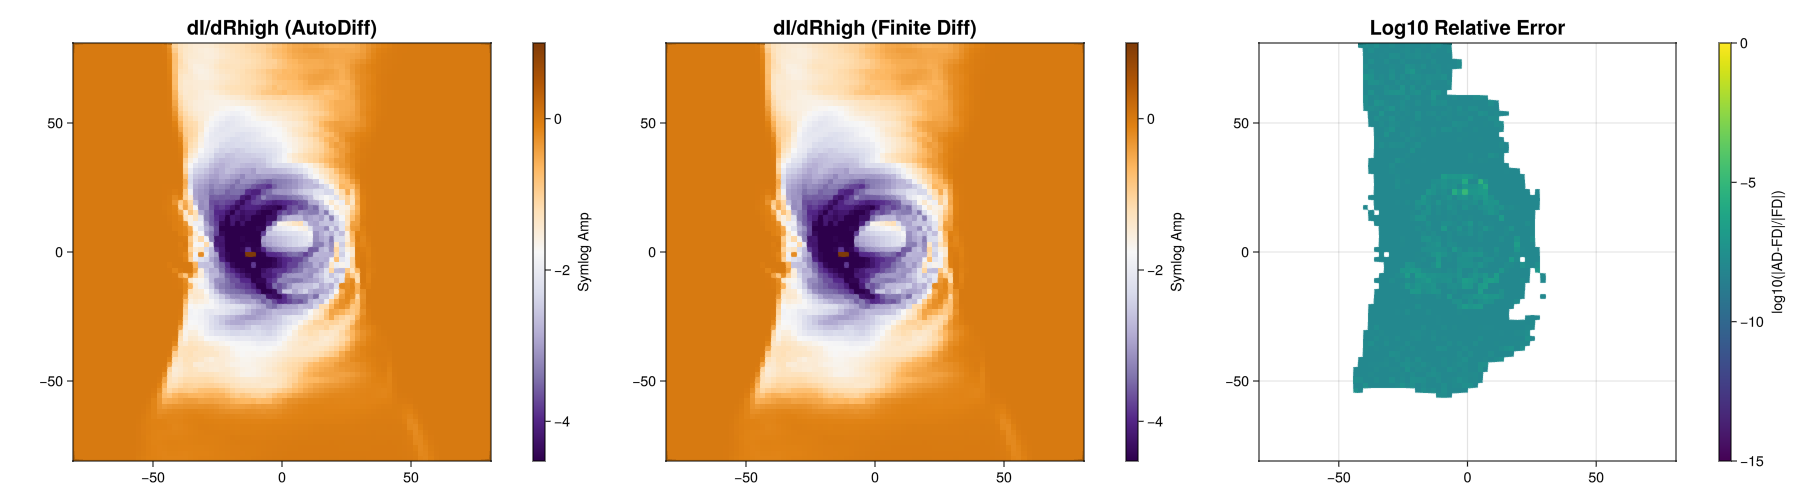

In [26]:
using GLMakie
using Statistics

# -----------------------------
# 1. Run Finite Differences
# -----------------------------
println("Running Finite Differences verification...")
# (Assuming dI_dRhigh_FD is already computed or available)
# dI_dRhigh_FD, _ = ... 

# -----------------------------
# 2. Relative Error Calculation
# -----------------------------
# Define a small epsilon to avoid dividing by absolute zero
epsilon = 1e-20 

# Calculate Relative Error: |AD - FD| / |FD|
# We add epsilon to the denominator to prevent Inf
numerator = abs.(dI_dRhigh_arr .- dI_dRhigh_FD)
denominator = abs.(dI_dRhigh_FD) .+ epsilon
rel_err_raw = numerator ./ denominator

# Log10 scale for viewing error orders of magnitude
# We clip the bottom at -8 (10^-8 error) to avoid log(0) issues
rel_err_log = log10.(clamp.(rel_err_raw, 1e-8, 10.0))

# OPTIONAL: Mask out the "background" where FD signal is extremely weak.
# Relative error in empty space (0 vs 0) is noisy and meaningless.
# We set pixels to NaN if the FD signal is less than 0.1% of the peak signal.
fd_peak = maximum(abs.(filter(!isnan, dI_dRhigh_FD)))
signal_mask = abs.(dI_dRhigh_FD) .> (1e-4 * fd_peak)

# Apply mask: Set background pixels to NaN (transparent in GLMakie)
rel_err_plot = copy(rel_err_log)
rel_err_plot[.!signal_mask] .= NaN

# -----------------------------
# 3. Symlog Setup for AD/FD
# -----------------------------
valid_indices_AD = findall(isfinite, dI_dRhigh_arr)
valid_indices_FD = findall(isfinite, dI_dRhigh_FD)
all_values = vcat(dI_dRhigh_arr[valid_indices_AD], dI_dRhigh_FD[valid_indices_FD])

avg_mag = mean(abs.(all_values))
linthresh_R = 1e-2 * avg_mag 

vmin_val = quantile(all_values, 0.01)
vmax_val = quantile(all_values, 0.99)

if vmin_val > 0; vmin_val = -linthresh_R; end
if vmax_val < 0; vmax_val =  linthresh_R; end

# Symlog Helper
function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

# Symlog Scalar Helper for Colorbar Limits
function symlog_scalar(x, linthresh)
    if abs(x) <= linthresh
        return x / linthresh
    else
        return sign(x) * (1 + log10(abs(x) / linthresh))
    end
end

dI_AD_log = symlog(dI_dRhigh_arr; linthresh=linthresh_R)
dI_FD_log = symlog(dI_dRhigh_FD;  linthresh=linthresh_R)

cr_symlog_R = (symlog_scalar(vmin_val, linthresh_R), symlog_scalar(vmax_val, linthresh_R))

# -----------------------------
# 4. Figure Layout (3 Panels)
# -----------------------------
fig = Figure(size = (1800, 500))

# --- Plot 1: AutoDiff ---
ax1 = Axis(fig[1, 1], title = "dI/dRhigh (AutoDiff)", aspect = DataAspect(), titlesize=20)
hm1 = heatmap!(ax1, x_coords, y_coords, dI_AD_log; colormap = Reverse(:PuOr), colorrange = cr_symlog_R)
Colorbar(fig[1, 2], hm1, label = "Symlog Amp")

# --- Plot 2: Finite Diff ---
ax2 = Axis(fig[1, 3], title = "dI/dRhigh (Finite Diff)", aspect = DataAspect(), titlesize=20)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_FD_log; colormap = Reverse(:PuOr), colorrange = cr_symlog_R)
Colorbar(fig[1, 4], hm2, label = "Symlog Amp")

# --- Plot 3: Relative Error ---
ax3 = Axis(fig[1, 5], title = "Log10 Relative Error", aspect = DataAspect(), titlesize=20)
# Use 'nan_color=:black' or transparent to hide background noise
hm3 = heatmap!(ax3, x_coords, y_coords, rel_err_plot; 
    colormap = :viridis, 
    colorrange = (-15, 0), # From 10^-4 (0.01%) to 10^0 (100%)
    nan_color = :transparent
)
Colorbar(fig[1, 6], hm3, label = "log10(|AD-FD|/|FD|)")

# Print stats
median_err = median(filter(!isnan, rel_err_raw[signal_mask]))
println("Median Relative Error (in signal region): $(median_err * 100) %")

fig

# Finite Differences

In [9]:
maxnstep = 15000
h = 1e-6
dI_dth_FD = FiniteDifferencesθ(ro, th, phi, DXsize, DYsize, pixels_x, pixels_y, SourceD, freq, maxnstep,h, bhspin, Rout, Rstop, simulation_data)


([-1.9458860492581584e-23 -7.472247633656455e-24 … -1.2752468749014638e-24 -7.905301788308665e-25; -1.9219860691516677e-23 -1.549953845015254e-23 … -1.2880318071310283e-23 -7.826034995867824e-24; … ; -6.903390350233079e-33 -1.4275744720069797e-33 … -2.768116427904275e-25 -1.1334726772908691e-25; -7.149219972193779e-34 -9.990609365081456e-34 … -9.574510217805124e-27 -1.3581255830856988e-27], [5.86242301516776e-23 2.9512424029297373e-23 … 5.115698527410714e-24 2.7712723005206278e-24; 1.4414080592846992e-22 7.135028625236483e-23 … 8.493853609969309e-23 4.116120553599959e-23; … ; 5.876776994033906e-33 1.9014416674940097e-33 … 8.610575546185292e-25 5.514263144976012e-25; 3.0995721039301816e-33 2.2821544816009292e-33 … 3.9901690126823477e-26 1.50179904299961e-26])

In [30]:
using DelimitedFiles

writedlm("./dI_dth_FD.txt", dI_dth_FD[1])
writedlm("./dI_dth_AD.txt", dI_dθo_arr)



# Conjugate gradient parameter recovery

### Parameter Recovery via Conjugate Gradient

In this cell, we use the **conjugate gradient algorithm** to recover the **ground truth black hole spin (`a`)** and **observer inclination (`θ`)** from the computed intensity map (`I_arr`).  

- `spin_value` and `initial_th_guess` provide the starting point for the optimization.  
- `true_conjugate_gradient_optimization` iteratively adjusts the parameters to minimize the difference between the **ground truth intensity** and the intensity predicted by the current parameter guess.  
- The outputs are:  
  - `ths` → recovered inclination values over iterations  
  - `err` → error at each iteration  
  - `steps` → number of iterations taken  

This procedure demonstrates **gradient-based parameter estimation** using the derivatives computed with autodiff.


In [17]:
include("../src/main.jl")
spin_value = 0.9375
initial_th_guess = 89.47
Rhigh_test = 20.0
ths, _, err, steps = true_conjugate_gradient_optimization_GRMHD(I_arr, ro, initial_th_guess, Rhigh_test, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 5e-8, optimize_param = :theta, dump_filepath = dump_filepath)

Using model: iharm, change src/set_globals.jl to modify.
Loading data from '../src/models/iharm3dDumps/dump_001.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 64, 32)
Optimization mode: theta
Optimizing θo: true, Optimizing Rhigh: false

 Running AutoDiffGeoTrajEulerMethod with θo = 89.47, Rhigh = 20.0 and applying σ_pixels = 0.0 filter
  Convergence check: cost=0.0012289975671216423, grad_norm=0.005137675080901382
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 0.0012289975671216423, Initial θo: 89.47, Initial Rhigh: 20.0
Initial gradient norm: 0.005137675080901382

--- Iteration 1 ---
Trying initial stepsize of 58.39217063671654, set at iteration 1
Cost before line search: 0.0012289975671216423
Using cached computation for x = [1.4911666666666668, 0.008]
grad = [0.005137675080901382, 0.0], direction = [-0.005137675080901382, 0.0]
  Line search: f0=0.0012289975671216423, df0=-2.6395705236915026e-5, initial_step=58.3921706

LoadError: TaskFailedException

[91m    nested task error: [39mInterruptException:
    Stacktrace:
      [1] [0m[1mrem_internal[22m[0m[1m([22m[90mx[39m::[0mFloat64, [90my[39m::[0mFloat64[0m[1m)[22m
    [90m    @[39m [90mBase[39m [90m./[39m[90m[4mfloat.jl:533[24m[39m
      [2] [0m[1mrem[22m
    [90m    @[39m [90m./[39m[90m[4mfloat.jl:601[24m[39m[90m [inlined][39m
      [3] [0m[1mXtoijk_ghost![22m[0m[1m([22m[90mX[39m::[0mMVector[90m{4, Float64}[39m, [90mdel[39m::[0mVector[90m{Float64}[39m[0m[1m)[22m
    [90m    @[39m [35mMain[39m [90m~/Jipole/src/[39m[90m[4mgrid.jl:20[24m[39m
      [4] [0m[1minterp_scalar[22m[0m[1m([22m[90mX[39m::[0mMVector[90m{4, Float64}[39m, [90mdata[39m::[0mArray[90m{Float64, 3}[39m[0m[1m)[22m
    [90m    @[39m [35mMain[39m [90m~/Jipole/src/[39m[90m[4mgrid.jl:140[24m[39m
      [5] [0m[1minterp_scalar_time[22m
    [90m    @[39m [90m~/Jipole/src/[39m[90m[4mgrid.jl

In [ ]:
include("../src/main.jl")
spin_value = 0.9375
initial_th_guess = 89.47
Rhigh_test = 20.0
ths, _, err, steps = true_conjugate_gradient_optimization_GRMHD(I_arr, ro, initial_th_guess, Rhigh_test, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 5e-8, optimize_param = :theta, dump_filepath = dump_filepath)

Using model: iharm, change src/set_globals.jl to modify.
Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)
Optimization mode: theta
Optimizing θo: true, Optimizing Rhigh: false

 Running AutoDiffGeoTrajEulerMethod with θo = 89.47, Rhigh = 20.0 and applying σ_pixels = 0.0 filter
  Convergence check: cost=0.003195650266388007, grad_norm=0.007377762075354108
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 0.003195650266388007, Initial θo: 89.47, Initial Rhigh: 20.0
Initial gradient norm: 0.007377762075354108

--- Iteration 1 ---
Trying initial stepsize of 40.66273714656229, set at iteration 1
Cost before line search: 0.003195650266388007
Using cached computation for x = [1.4911666666666668, 0.008]
grad = [0.007377762075354108, 0.0], direction = [-0.007377762075354108, 0.0]
  Line search: f0=0.003195650266388007, df0=-5.443137324053335e-5, initial_s

Internal error: during type inference of
error_content(LoadError, Array{Union{Ptr{Nothing}, Base.InterpreterIP}, 1})
Encountered unexpected error in runtime:
InterruptException()
push! at ./../usr/share/julia/Compiler/src/inferencestate.jl:48
jfptr_pushNOT._5955.1 at /home/pedro/.julia/juliaup/julia-1.12.3+0.x64.linux.gnu/lib/julia/sys.so (unknown line)
tojlinvoke85076.1 at /home/pedro/.julia/juliaup/julia-1.12.3+0.x64.linux.gnu/lib/julia/sys.so (unknown line)
j_pushNOT._77055.1 at /home/pedro/.julia/juliaup/julia-1.12.3+0.x64.linux.gnu/lib/julia/sys.so (unknown line)
BBScanner at ./../usr/share/julia/Compiler/src/ssair/irinterp.jl:273 [inlined]
#ir_abstract_constant_propagation#214 at ./../usr/share/julia/Compiler/src/ssair/irinterp.jl:325
ir_abstract_constant_propagation at ./../usr/share/julia/Compiler/src/ssair/irinterp.jl:318
semi_concrete_eval_call at ./../usr/share/julia/Compiler/src/abstractinterpretation.jl:1266
abstract_call_method_with_const_args at ./../usr/share/julia/Comp

In [16]:
include("../src/main.jl")
spin_value = 0.9375
initial_th_guess = 21.00
Rhigh_test = 20.0
ths, _, err, steps = true_conjugate_gradient_optimization_GRMHD(I_arr, ro, initial_th_guess, Rhigh_test, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 5e-8, optimize_param = :theta, dump_filepath = dump_filepath,  sensemode = "FD")

Using model: iharm, change src/set_globals.jl to modify.
Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)
Optimization mode: theta
Optimizing θo: true, Optimizing Rhigh: false

 Running AutoDiffGeoTrajEulerMethod with θo = 21.0, Rhigh = 20.0 and applying σ_pixels = 0.0 filter
Using Finite Differences to compute gradients
scale_factor = 9.401754552731624
Calculating High (+h)...
Calculating Low (-h)...
Calculating Central...
  Convergence check: cost=3.0792452342106534e-5, grad_norm=5.403520630611629e-5
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 3.0792452342106534e-5, Initial θo: 21.0, Initial Rhigh: 20.0
Initial gradient norm: 5.403520630611629e-5

--- Iteration 1 ---
Trying initial stepsize of 5551.935867524258, set at iteration 1
Cost before line search: 3.0792452342106534e-5
Using cached computation for x = [0.35, 0.008]
grad = [5.40352

┌ Warning: Line search failed to find any improvement
└ @ Main ~/Jipole/src/gradientdescent.jl:320


Line search completed: new cost = 3.0792452342106534e-5, step size = 0.0
Initial cost after line search: 3.0792452342106534e-5
Cost improvement: 0.0 (relative: 0.0)
No significant improvement in line search, trying steepest descent
Using cached computation for x = [0.35, 0.008]
grad = [5.403520630611629e-5, 0.0], direction = [-5.403520630611629e-5, 0.0]
  Line search: f0=3.0792452342106534e-5, df0=-2.9198035205445493e-9, initial_step=0.01

 Running AutoDiffGeoTrajEulerMethod with θo = 20.999967578876216, Rhigh = 20.0 and applying σ_pixels = 0.0 filter
Using Finite Differences to compute gradients
scale_factor = 9.401754552731624
Calculating High (+h)...
Calculating Low (-h)...
Calculating Central...
  Step 1: step_size=0.01, f_new=3.0792383480104136e-5, improvement=6.886200239723675e-11, Rhigh tested = 0.96, θo tested = 20.999967578876216
  Armijo condition satisfied!
 New cost function value: 3.0792383480104136e-5


┌ Warning: No improvement possible, stopping optimization
└ @ Main ~/Jipole/src/gradientdescent.jl:971
┌ Warning: Maximum iterations reached without convergence
└ @ Main ~/Jipole/src/gradientdescent.jl:1083


([21.0, 21.0], [20.0, 20.0], [3.0792452342106534e-5, 3.0792452342106534e-5], 200)

In [ ]:
include("../src/main.jl")
spin_value = 0.9375
initial_th_guess = 80.0
Rhigh_test = 17.0
ths, _, err, steps = true_conjugate_gradient_optimization_GRMHD(I_arr, ro, initial_th_guess, Rhigh_test, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 5e-8, optimize_param = :both, dump_filepath = dump_filepath)

Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)
Optimization mode: both
Optimizing θo: true, Optimizing Rhigh: true
Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)

 Running AutoDiffGeoTrajEulerMethod with θo = 80.0, Rhigh = 17.0 and applying σ_pixels = 0.0 filter
  Convergence check: cost=1.4044478818690057e-5, grad_norm=0.017220548131746387
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 1.4044478818690057e-5, Initial θo: 80.0, Initial Rhigh: 17.0
Initial gradient norm: 0.017220548131746387

--- Iteration 1 ---
Trying initial stepsize of 17.421048256120528, set at iteration 1
Cost before line search: 1.4044478818690057e-5
Using cached computation for x = [1.3333333333333333, 0.0068]
grad = [0.017151426754353577, -0.0015413754402

Plot theta, spin and error evolution at each iteration step

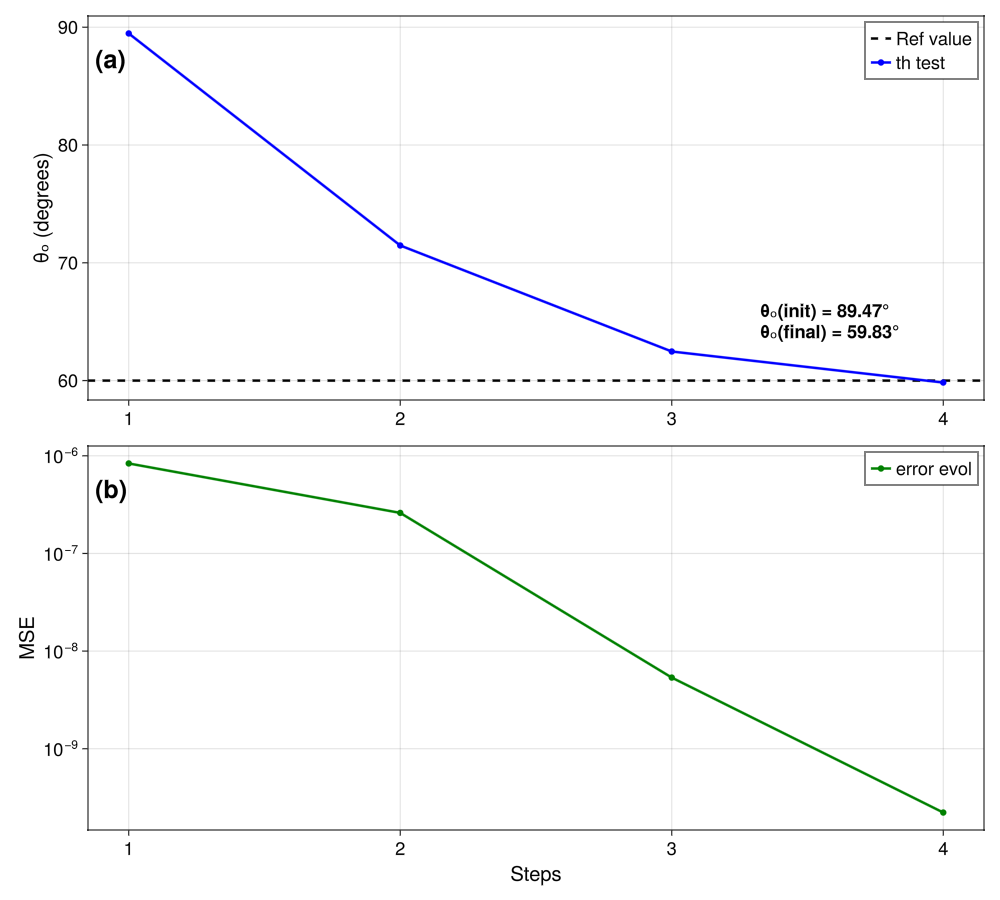

In [31]:
using GLMakie

fig = Figure(size = (1000, 900))
xticks = 0:9

# -----------------------------
# (a) Plot θₒ
# -----------------------------
ax1 = Axis(fig[1, 1], 
    ylabel = "θₒ (degrees)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax1, 60, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax1, 1:length(ths), ths, color = :blue, linewidth = 2.5, label = "th test")
axislegend(ax1, position = :rt, labelsize = 18)
text!(ax1, 0.008, 0.85, text = "(a)", space = :relative, fontsize = 25, font = :bold)

# Get initial and final values to print out on top of the figure
θ_init = ths[1]
θ_final = ths[end]


label_text = @sprintf("θₒ(init) = %.2f°\nθₒ(final) = %.2f°", θ_init, θ_final)

text!(
    ax1,
    0.75, 0.15,              
    text = label_text,
    space = :relative,
    fontsize = 18,
    align = (:left, :bottom),
    font = :bold
)

# -----------------------------
# (b) Plot Error
# -----------------------------
ax3 = Axis(fig[2, 1],
    xlabel = "Steps", ylabel = "MSE",
    yscale = log10,
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
scatterlines!(ax3, 1:length(err), err, color = :green, linewidth = 2.5, label = "error evol")
axislegend(ax3, position = :rt, labelsize = 18)
text!(ax3, 0.008, 0.85, text = "(b)", space = :relative, fontsize = 25, font = :bold)

# Link all x-axes
linkxaxes!(ax1, ax3)

# Display and save
#save("../imgs/th_convergence_noise_upper.png", fig)
fig

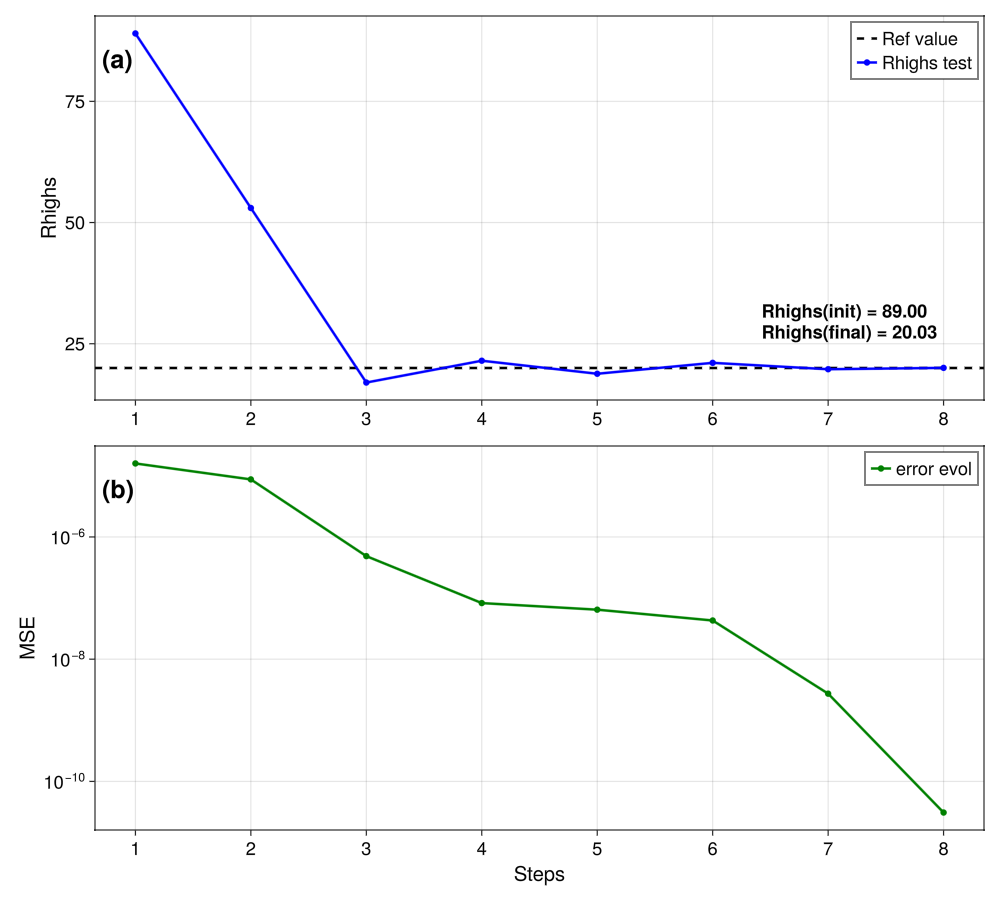

In [26]:
using GLMakie
using Printf

# 1. Define the Rhighs array
Rhighs = [89.0, 53.00000000000001, 17.000000000000007, 21.500000000000007, 
          18.812500000000007, 21.062500000000004, 19.746093750000004, 20.027343750000004]

# (Assumes 'err' array is already defined in your workspace)

fig = Figure(size = (1000, 900))
xticks = 0:9

# -----------------------------
# (a) Plot Rhighs
# -----------------------------
ax1 = Axis(fig[1, 1], 
    ylabel = "Rhighs",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)

# Added reference line at 20
hlines!(ax1, 20, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")

scatterlines!(ax1, 1:length(Rhighs), Rhighs, color = :blue, linewidth = 2.5, label = "Rhighs test")
axislegend(ax1, position = :rt, labelsize = 18)
text!(ax1, 0.008, 0.85, text = "(a)", space = :relative, fontsize = 25, font = :bold)

# Get initial and final values to print out on top of the figure
R_init = Rhighs[1]
R_final = Rhighs[end]

label_text = @sprintf("Rhighs(init) = %.2f\nRhighs(final) = %.2f", R_init, R_final)

text!(
    ax1,
    0.75, 0.15,              
    text = label_text,
    space = :relative,
    fontsize = 18,
    align = (:left, :bottom),
    font = :bold
)

# -----------------------------
# (b) Plot Error
# -----------------------------
ax3 = Axis(fig[2, 1],
    xlabel = "Steps", ylabel = "MSE",
    yscale = log10,
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)

scatterlines!(ax3, 1:length(err), err, color = :green, linewidth = 2.5, label = "error evol")
axislegend(ax3, position = :rt, labelsize = 18)
text!(ax3, 0.008, 0.85, text = "(b)", space = :relative, fontsize = 25, font = :bold)

# Link all x-axes
linkxaxes!(ax1, ax3)

# Display
fig

# With Noise

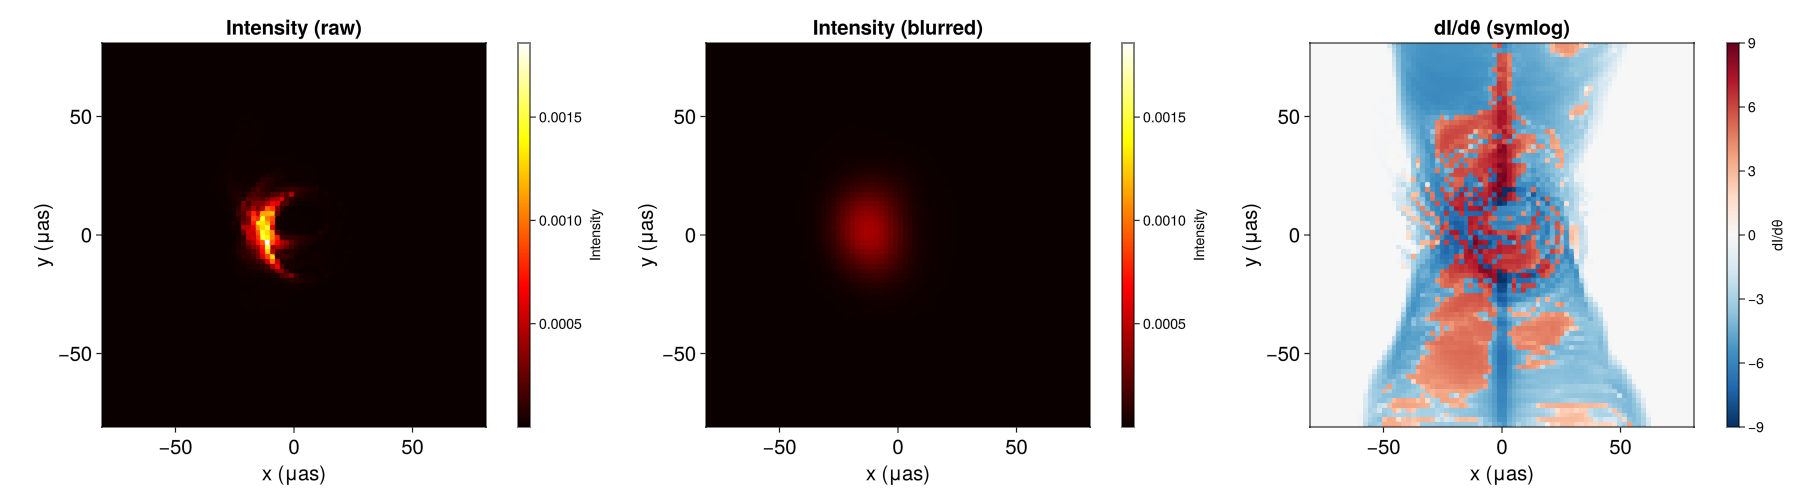

In [26]:
using GLMakie
using FFTW, Random, ImageFiltering

# =============================
# Physical / angular parameters
# =============================
d_kpc = 16900
d_cm  = d_kpc * 3.086e21

fov_rg      = 44.172
half_fov_rg = fov_rg / 2

# Must exist in your session:
# L_unit, MUAS_PER_RAD, pixels_x, nx, ny
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

pixels_per_muas = pixels_x / (2 * theta_μas)
σ_pixels = (pixels_per_muas * 20) / 2.3548   # 20 μas FWHM

# =============================
# Blur intensity
# =============================
Random.seed!(1234)
Iblur = imfilter(I_arr, Kernel.gaussian(σ_pixels))

# =============================
# Coordinates (μas)
# =============================
x_coords = range(-theta_μas, theta_μas, length = nx)
y_coords = range(-theta_μas, theta_μas, length = ny)

# =============================
# Symlog parameters
# =============================
vmin = -1e-3
vmax =  1e-3
linthresh = 1e-3 * vmax   # = 1e-6

# =============================
# Symlog transform
# =============================
function symlog(x; linthresh)
    absx  = abs.(x)
    signx = sign.(x)
    y = similar(x)

    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))

    return y
end

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh = linthresh)

cr_symlog = (
    -(1 + log10(abs(vmin) / linthresh)),
     (1 + log10(abs(vmax) / linthresh))
)

# =============================
# Figure layout
# =============================
fig = Figure(size = (1800, 500))

cr_I = extrema(I_arr)

# =============================
# Panel 1: Raw intensity
# =============================
ax1 = Axis(fig[1, 1],
    title = "Intensity (raw)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = 20, yticklabelsize = 20
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr;
    colormap = :hot,
    colorrange = cr_I
)

Colorbar(fig[1, 2], hm1; label = "Intensity")

# =============================
# Panel 2: Blurred intensity
# =============================
ax_mid = Axis(fig[1, 3],
    title = "Intensity (blurred)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = 20, yticklabelsize = 20
)

hm_mid = heatmap!(ax_mid, x_coords, y_coords, Iblur;
    colormap = :hot,
    colorrange = cr_I
)

Colorbar(fig[1, 4], hm_mid; label = "Intensity")

# =============================
# Panel 3: dI/dθ (symlog)
# =============================
ax2 = Axis(fig[1, 5],
    title = "dI/dθ (symlog)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = 20, yticklabelsize = 20
)

hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog
)

Colorbar(fig[1, 6], hm2; label = "dI/dθ")
#save("../imgs/Img_with_noise.png", fig)

# =============================
# Display
# =============================
fig
